In [ ]:
# Scope note (Singapore GP multi-year):
# We will support Singapore GP data from 2018–2025, but analysis will be regulation-aware.
# The pipeline is first proven on a single year/session (core deliverable), then scaled.
# Multi-year results are computed per era (2018–21 vs 2022–25) or per year, avoiding a
# misleading “one-size-fits-all” ideal envelope across fundamentally different car regs.
#
# Rationale: increasing years increases heterogeneity (track evolution + car regs + telemetry
# differences). We treat multi-year expansion as validation/comparison, not as a single pooled
# training set.

In [ ]:
# ============================
# Scope Plan (Singapore GP Telemetry Coach)
# ============================
# We will build this project in 3 scope layers to stay coherent and debuggable.
#
# Layer 1 — Single-year MVP (2025 only)
# - Start with Singapore GP 2025 (one session type, preferably Qualifying).
# - Deliver: sector + mini-sector time-loss attribution + corner-complex diagnostics.
# - Purpose: prove the full pipeline works end-to-end (load -> align -> features -> scoring).
#
# Layer 2 — Regulation-limited expansion (avoid confounding)
# - Expand to a regulation-consistent set first (e.g., 2022–2025 ground-effect era).
# - Learn “ideal envelopes” and time-loss mappings within this era only.
# - Purpose: scale data volume while keeping vehicle behavior comparable.
#
# Layer 3 — All available years (validation/comparison, not one pooled dataset)
# - Expand to all Singapore GP years available (e.g., 2018–2025).
# - Analyze per year or per regulation era (2018–2021 vs 2022–2025), then compare shifts:
#   braking points, curvature/radius profiles, throttle pickup, and time-loss drivers.
# - Explicitly avoid claiming one universal “ideal” across all years without conditioning.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("../../data_processed/singapore_gp/quali/year=2025")

laps_path = DATA_DIR / "laps.parquet"
tel_path  = DATA_DIR / "telemetry.parquet"

laps = pd.read_parquet(laps_path)
tel  = pd.read_parquet(tel_path)

print("laps:", laps.shape, "| telemetry:", tel.shape)
print("unique LapId (laps):", laps["LapId"].nunique())
print("unique LapId (tel):", tel["LapId"].nunique())

laps: (298, 17) | telemetry: (61255, 11)
unique LapId (laps): 298
unique LapId (tel): 89


In [2]:
# Minimal cleaning
tel = tel.dropna(subset=["LapId", "Distance", "TimeSeconds", "Speed"])

# Ensure types
tel["Distance"] = tel["Distance"].astype(float)
tel["TimeSeconds"] = tel["TimeSeconds"].astype(float)

# Sort for correct delta computations
tel = tel.sort_values(["LapId", "Distance"]).reset_index(drop=True)

# Keep only LapIds that exist in laps.parquet
tel = tel[tel["LapId"].isin(set(laps["LapId"]))].copy()

print("telemetry after filter:", tel.shape)

telemetry after filter: (61255, 11)


In [4]:
import pandas as pd
import numpy as np

tel = pd.read_parquet("../../data_processed/singapore_gp/quali/year=2025/telemetry.parquet")

# pick ONE lap to start (debuggable)
lap_id = tel["LapId"].iloc[0]
lap_tel = tel[tel["LapId"] == lap_id].copy()

lap_tel = lap_tel.sort_values("TimeSeconds").reset_index(drop=True)

print("LapId:", lap_id, "| rows:", len(lap_tel))

LapId: 2025_18_Q_63_2.0 | rows: 684


In [5]:
def kalman_filter_xy(time, x_meas, y_meas):
    n = len(time)

    # State: [x, y, vx, vy]
    xhat = np.zeros((n, 4))

    # Initial state
    xhat[0, 0] = x_meas.iloc[0]
    xhat[0, 1] = y_meas.iloc[0]
    xhat[0, 2] = 0.0
    xhat[0, 3] = 0.0

    P = np.eye(4) * 10.0  # initial uncertainty

    # Measurement noise (tune if needed)
    R = np.diag([2.0, 2.0])  # meters^2

    # Process noise
    q = 0.5
    Q = np.diag([0.0, 0.0, q, q])

    # Measurement matrix
    H = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0]
    ])

    I = np.eye(4)

    for k in range(1, n):
        dt = time.iloc[k] - time.iloc[k-1]
        if dt <= 0:
            dt = 1e-3

        # State transition
        F = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1,  0],
            [0, 0, 0,  1]
        ])

        # Predict
        x_pred = F @ xhat[k-1]
        P_pred = F @ P @ F.T + Q

        # Measurement update
        z = np.array([x_meas.iloc[k], y_meas.iloc[k]])
        y_res = z - H @ x_pred
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        xhat[k] = x_pred + K @ y_res
        P = (I - K @ H) @ P_pred

    return xhat

In [6]:
xhat = kalman_filter_xy(
    lap_tel["TimeSeconds"],
    lap_tel["X"],
    lap_tel["Y"]
)

lap_tel["x_smooth"]  = xhat[:, 0]
lap_tel["y_smooth"]  = xhat[:, 1]
lap_tel["vx_smooth"] = xhat[:, 2]
lap_tel["vy_smooth"] = xhat[:, 3]

In [7]:
# Heading from velocity vector
lap_tel["heading"] = np.arctan2(lap_tel["vy_smooth"], lap_tel["vx_smooth"])

# Distance derivative
ds = np.gradient(lap_tel["Distance"].values)
dpsi = np.gradient(lap_tel["heading"].values)

# Curvature kappa ≈ d(heading)/ds
lap_tel["curvature"] = np.where(ds > 0, dpsi / ds, 0.0)

# Lateral acceleration proxy
lap_tel["lat_accel"] = (lap_tel["Speed"] / 3.6) ** 2 * lap_tel["curvature"]

In [8]:
##

In [26]:
import numpy as np

import numpy as np

raw = lap_tel.copy()

# 1) heading from raw X/Y
dx = np.gradient(raw["X"].values)
dy = np.gradient(raw["Y"].values)
raw["heading_raw"] = np.arctan2(dy, dx)

# 2) unwrap heading (IMPORTANT)
raw["heading_raw_u"] = np.unwrap(raw["heading_raw"].values)

# 3) curvature = d(heading)/ds  (use nan when ds is tiny)
ds_raw = np.gradient(raw["Distance"].values)
dpsi_raw = np.gradient(raw["heading_raw_u"].values)

eps = 1e-6
raw["curvature_raw_fix"] = dpsi_raw / np.where(np.abs(ds_raw) < eps, np.nan, ds_raw)

# 4) lateral accel proxy (m/s^2)
v_raw = raw["Speed"].values / 3.6
raw["lat_accel_raw_fix"] = v_raw**2 * raw["curvature_raw_fix"]

# optional: clip only for plotting (doesn't change your "true" values)
raw["curvature_raw_plot"] = raw["curvature_raw_fix"].clip(-0.1, 0.1)
raw["lat_accel_raw_plot"] = raw["lat_accel_raw_fix"].clip(-60, 60)

#########################################################################
kf = lap_tel.copy()

# 1) heading from Kalman velocity vector
kf["heading_kf"] = np.arctan2(kf["vy_smooth"].values, kf["vx_smooth"].values)

# 2) unwrap heading
kf["heading_kf_u"] = np.unwrap(kf["heading_kf"].values)

# 3) curvature
ds_kf = np.gradient(kf["Distance"].values)
dpsi_kf = np.gradient(kf["heading_kf_u"].values)

eps = 1e-6
kf["curvature_kf_fix"] = dpsi_kf / np.where(np.abs(ds_kf) < eps, np.nan, ds_kf)

# 4) lateral accel proxy
v_kf = kf["Speed"].values / 3.6
kf["lat_accel_kf_fix"] = v_kf**2 * kf["curvature_kf_fix"]

# optional plotting clips
kf["curvature_kf_plot"] = kf["curvature_kf_fix"].clip(-0.1, 0.1)
kf["lat_accel_kf_plot"] = kf["lat_accel_kf_fix"].clip(-60, 60)

In [27]:
import numpy as np

raw["heading_raw_u"] = np.unwrap(raw["heading_raw"].values)
kf["heading_kf_u"]   = np.unwrap(kf["heading_kf"].values)

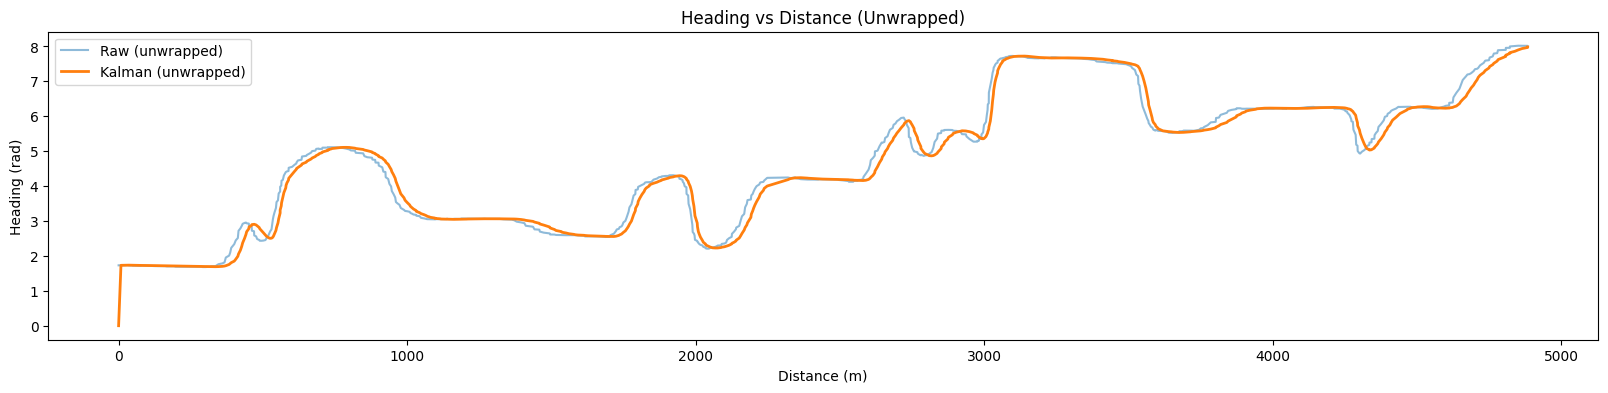

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,4))
plt.plot(raw["Distance"], raw["heading_raw_u"], alpha=0.5, label="Raw (unwrapped)")
plt.plot(kf["Distance"], kf["heading_kf_u"], linewidth=2, label="Kalman (unwrapped)")
plt.xlabel("Distance (m)")
plt.ylabel("Heading (rad)")
plt.title("Heading vs Distance (Unwrapped)")
plt.legend()
plt.show()

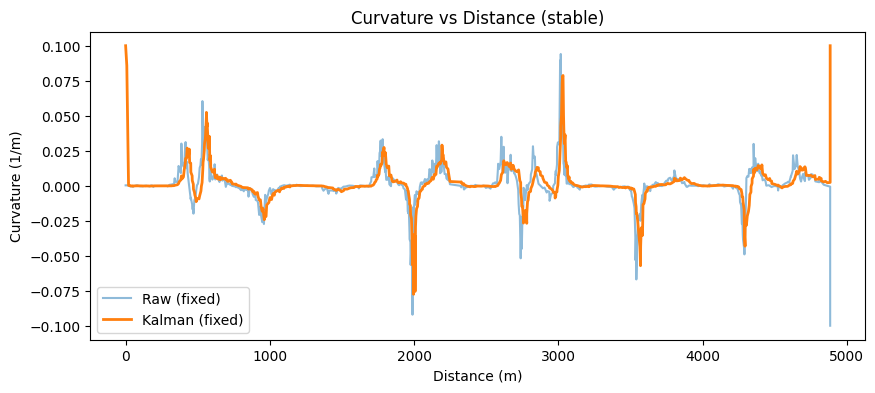

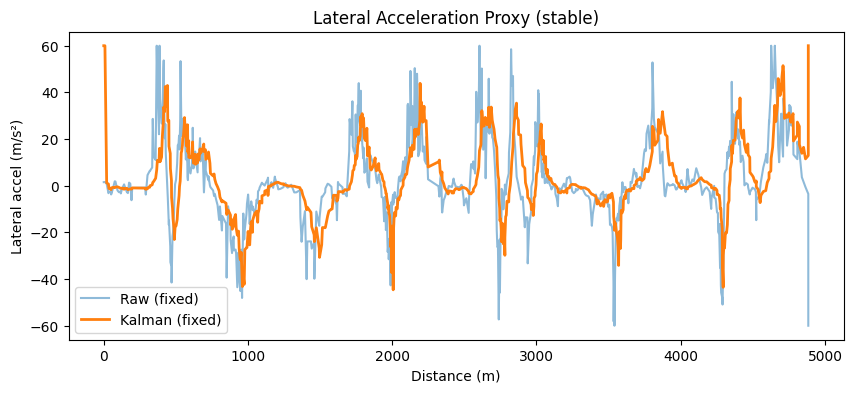

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(raw["Distance"], raw["curvature_raw_plot"], alpha=0.5, label="Raw (fixed)")
plt.plot(kf["Distance"],  kf["curvature_kf_plot"],  linewidth=2, label="Kalman (fixed)")
plt.xlabel("Distance (m)")
plt.ylabel("Curvature (1/m)")
plt.title("Curvature vs Distance (stable)")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(raw["Distance"], raw["lat_accel_raw_plot"], alpha=0.5, label="Raw (fixed)")
plt.plot(kf["Distance"],  kf["lat_accel_kf_plot"],  linewidth=2, label="Kalman (fixed)")
plt.xlabel("Distance (m)")
plt.ylabel("Lateral accel (m/s²)")
plt.title("Lateral Acceleration Proxy (stable)")
plt.legend()
plt.show()

In [31]:
BIN_SIZE = 25  # meters

kf["mini_sector"] = (kf["Distance"] // BIN_SIZE).astype(int)

In [32]:
mini = (
    kf.groupby("mini_sector")
      .agg(
          dist_start=("Distance", "min"),
          dist_end=("Distance", "max"),

          mean_speed=("Speed", "mean"),
          min_speed=("Speed", "min"),

          mean_curvature=("curvature_kf_fix", "mean"),
          max_curvature=("curvature_kf_fix", "max"),

          peak_lat_accel=("lat_accel_kf_fix", "max"),
      )
      .reset_index()
)

In [33]:
REF_LAPID = fastest_lap_id

NameError: name 'fastest_lap_id' is not defined

In [34]:
mini_ref

NameError: name 'mini_ref' is not defined

In [36]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../../data_processed/singapore_gp/quali/year=2025")

laps = pd.read_parquet(DATA_DIR / "laps.parquet")

# Fastest lap in this session
laps_nonnull = laps.dropna(subset=["LapTime"]).copy()
fastest_row = laps_nonnull.loc[laps_nonnull["LapTime"].idxmin()]

fastest_lap_id = fastest_row["LapId"]
REF_LAPID = fastest_lap_id

print("REF_LAPID:", REF_LAPID)
print("Driver:", fastest_row["Driver"], "| LapTime:", fastest_row["LapTime"])

REF_LAPID: 2025_18_Q_63_17.0
Driver: RUS | LapTime: 0 days 00:01:29.158000


In [37]:
import numpy as np
import pandas as pd

tel = pd.read_parquet(DATA_DIR / "telemetry.parquet")

# Filter to reference lap telemetry
lap_tel_ref = tel[tel["LapId"] == REF_LAPID].copy()
lap_tel_ref = lap_tel_ref.sort_values("TimeSeconds").reset_index(drop=True)

print("ref rows:", len(lap_tel_ref))
lap_tel_ref.head()

ref rows: 673


,Distance,Speed,Throttle,Brake,X,Y,TimeSeconds,LapId,Driver,DriverNumber,LapNumber
0,0.068381,273.560003,100.0,False,1032.113824,-327.973084,0.000,2025_18_Q_63_17.0,RUS,63,17.0
1,6.822497,275.320003,100.0,False,1023.000000,-273.000000,0.088,2025_18_Q_63_17.0,RUS,63,17.0
2,9.440000,276.000000,100.0,False,1019.303071,-250.800568,0.122,2025_18_Q_63_17.0,RUS,63,17.0
3,33.203708,279.399999,100.0,False,983.000000,-30.000000,0.428,2025_18_Q_63_17.0,RUS,63,17.0
4,37.440000,280.000000,100.0,False,976.542081,11.740053,0.482,2025_18_Q_63_17.0,RUS,63,17.0


In [38]:
# ---- Kalman state estimate (x,y,vx,vy) ----
xhat = kalman_filter_xy(
    lap_tel_ref["TimeSeconds"],
    lap_tel_ref["X"],
    lap_tel_ref["Y"]
)

kf_ref = lap_tel_ref.copy()
kf_ref["x_smooth"]  = xhat[:, 0]
kf_ref["y_smooth"]  = xhat[:, 1]
kf_ref["vx_smooth"] = xhat[:, 2]
kf_ref["vy_smooth"] = xhat[:, 3]

# ---- Heading (unwrap) ----
kf_ref["heading_kf"]   = np.arctan2(kf_ref["vy_smooth"].values, kf_ref["vx_smooth"].values)
kf_ref["heading_kf_u"] = np.unwrap(kf_ref["heading_kf"].values)

# ---- Curvature + lateral accel (your fixed version) ----
ds = np.gradient(kf_ref["Distance"].values)
dpsi = np.gradient(kf_ref["heading_kf_u"].values)

eps = 1e-6
kf_ref["curvature_kf_fix"] = dpsi / np.where(np.abs(ds) < eps, np.nan, ds)

v = kf_ref["Speed"].values / 3.6
kf_ref["lat_accel_kf_fix"] = v**2 * kf_ref["curvature_kf_fix"]

In [39]:
BIN_SIZE = 25  # meters
kf_ref["mini_sector"] = (kf_ref["Distance"] // BIN_SIZE).astype(int)

mini_ref = (
    kf_ref.groupby("mini_sector")
          .agg(
              dist_start=("Distance", "min"),
              dist_end=("Distance", "max"),
              mean_speed=("Speed", "mean"),
              min_speed=("Speed", "min"),
              mean_curvature=("curvature_kf_fix", "mean"),
              max_curvature=("curvature_kf_fix", "max"),
              peak_lat_accel=("lat_accel_kf_fix", "max"),
          )
          .reset_index()
)

mini_ref.head()

,mini_sector,dist_start,dist_end,mean_speed,min_speed,mean_curvature,max_curvature,peak_lat_accel
0,0,0.068381,9.440000,274.960002,273.560003,0.147340,0.256894,1483.383585
1,1,33.203708,47.377058,280.550000,279.399999,-0.000141,-0.000083,-0.497486
2,2,59.606667,71.350230,286.102500,285.000000,-0.000123,-0.000094,-0.586358
3,3,75.606667,84.241106,288.596101,288.000000,-0.000175,-0.000122,-0.789931
4,4,104.725556,108.633440,292.150000,292.000000,-0.000113,-0.000109,-0.719438


In [40]:
print("mini_ref rows (num bins):", len(mini_ref))
print("distance span:", mini_ref["dist_start"].min(), "->", mini_ref["dist_end"].max())

mini_ref rows (num bins): 193
distance span: 0.06838127476713152 -> 4881.63560994691


In [41]:
all_mini = []

for lap_id in tel["LapId"].unique():
    lap_tel = tel[tel["LapId"] == lap_id].copy()
    lap_tel = lap_tel.sort_values("TimeSeconds").reset_index(drop=True)

    # run Kalman + curvature EXACTLY the same way as ref
    xhat = kalman_filter_xy(
        lap_tel["TimeSeconds"],
        lap_tel["X"],
        lap_tel["Y"]
    )

    lap_tel["vx_smooth"] = xhat[:, 2]
    lap_tel["vy_smooth"] = xhat[:, 3]

    lap_tel["heading_kf"] = np.arctan2(
        lap_tel["vy_smooth"].values,
        lap_tel["vx_smooth"].values
    )
    lap_tel["heading_kf_u"] = np.unwrap(lap_tel["heading_kf"].values)

    ds = np.gradient(lap_tel["Distance"].values)
    dpsi = np.gradient(lap_tel["heading_kf_u"].values)

    eps = 1e-6
    lap_tel["curvature_kf_fix"] = dpsi / np.where(np.abs(ds) < eps, np.nan, ds)

    v = lap_tel["Speed"].values / 3.6
    lap_tel["lat_accel_kf_fix"] = v**2 * lap_tel["curvature_kf_fix"]

    # mini-sectors
    lap_tel["mini_sector"] = (lap_tel["Distance"] // 25).astype(int)

    mini = (
        lap_tel.groupby("mini_sector")
               .agg(
                   LapId=("LapId", "first"),
                   mean_speed=("Speed", "mean"),
                   mean_curvature=("curvature_kf_fix", "mean"),
                   peak_lat_accel=("lat_accel_kf_fix", "max"),
               )
               .reset_index()
    )

    all_mini.append(mini)

mini_all = pd.concat(all_mini, ignore_index=True)

In [42]:
mini_all.head()
mini_all.shape

(17202, 5)

In [44]:
mini_delta = mini_all.merge(
    mini_ref,
    on="mini_sector",
    suffixes=("", "_ref"),
    how="inner"
)

# Deltas vs ideal (reference lap)
mini_delta["delta_speed"] = mini_delta["mean_speed"] - mini_delta["mean_speed_ref"]
mini_delta["delta_curvature"] = mini_delta["mean_curvature"] - mini_delta["mean_curvature_ref"]
mini_delta["delta_lat_accel"] = mini_delta["peak_lat_accel"] - mini_delta["peak_lat_accel_ref"]

mini_delta.head()

,mini_sector,LapId,mean_speed,mean_curvature,peak_lat_accel,dist_start,dist_end,mean_speed_ref,min_speed,mean_curvature_ref,max_curvature,peak_lat_accel_ref,delta_speed,delta_curvature,delta_lat_accel
0,0,2025_18_Q_63_2.0,270.854020,0.099436,1185.849653,0.068381,9.440000,274.960002,273.560003,0.147340,0.256894,1483.383585,-4.105982,-0.047904,-297.533933
1,1,2025_18_Q_63_2.0,274.487501,-0.000038,0.723776,33.203708,47.377058,280.550000,279.399999,-0.000141,-0.000083,-0.497486,-6.062499,0.000103,1.221262
2,2,2025_18_Q_63_2.0,280.991667,-0.000183,-0.699147,59.606667,71.350230,286.102500,285.000000,-0.000123,-0.000094,-0.586358,-5.110833,-0.000059,-0.112789
3,3,2025_18_Q_63_2.0,284.661111,-0.000100,-0.486756,75.606667,84.241106,288.596101,288.000000,-0.000175,-0.000122,-0.789931,-3.934989,0.000075,0.303176
4,4,2025_18_Q_63_2.0,290.166667,-0.000151,-0.739416,104.725556,108.633440,292.150000,292.000000,-0.000113,-0.000109,-0.719438,-1.983333,-0.000038,-0.019978


In [45]:
# Lap times
laps = pd.read_parquet(DATA_DIR / "laps.parquet")
laps_nonnull = laps.dropna(subset=["LapTime"]).copy()

laps_nonnull["LapTime_s"] = laps_nonnull["LapTime"].dt.total_seconds()

ref_time = laps_nonnull.loc[laps_nonnull["LapId"] == REF_LAPID, "LapTime_s"].iloc[0]

lap_targets = laps_nonnull[["LapId", "LapTime_s"]].copy()
lap_targets["delta_lap_time"] = lap_targets["LapTime_s"] - ref_time

In [46]:
lap_features = (
    mini_delta.groupby("LapId")
              .agg(
                  mean_delta_speed=("delta_speed", "mean"),
                  mean_delta_curvature=("delta_curvature", "mean"),
                  mean_delta_lat_accel=("delta_lat_accel", "mean"),

                  worst_speed_loss=("delta_speed", "min"),
                  worst_curvature_excess=("delta_curvature", "max"),
              )
              .reset_index()
)

dataset = lap_features.merge(
    lap_targets[["LapId", "delta_lap_time"]],
    on="LapId",
    how="inner"
)

dataset.head()

,LapId,mean_delta_speed,mean_delta_curvature,mean_delta_lat_accel,worst_speed_loss,worst_curvature_excess,delta_lap_time
0,2025_18_Q_10_5.0,-3.844813,-0.000118,1.392362,-25.468040,0.021796,2.103
1,2025_18_Q_12_10.0,-0.740485,-0.000113,-1.748195,-29.133337,0.026308,0.491
2,2025_18_Q_12_13.0,-0.678475,0.000062,-0.741159,-32.161299,0.029179,0.379
3,2025_18_Q_12_16.0,-0.898119,-0.000218,-3.276221,-37.626677,0.020112,0.603
4,2025_18_Q_12_4.0,-2.737080,-0.000128,-1.538364,-20.395408,0.016296,0.878


In [47]:
dataset.describe()

,mean_delta_speed,mean_delta_curvature,mean_delta_lat_accel,worst_speed_loss,worst_curvature_excess,delta_lap_time
count,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000
mean,-2.379922,0.000333,7.076007,-37.593457,0.100093,1.201742
std,1.352827,0.001113,19.609642,15.709713,0.186381,0.663314
min,-8.656593,-0.000602,-7.024423,-104.071569,0.000000,0.000000
25%,-3.094586,-0.000257,-3.281043,-41.953127,0.022086,0.710000
50%,-2.178336,-0.000073,-0.741159,-34.229157,0.029179,1.120000
75%,-1.479681,0.000456,6.195931,-28.971919,0.069770,1.587000
max,0.162391,0.005212,87.751128,0.000000,0.989353,3.830000


In [48]:
mini_ref[["mini_sector", "dist_start", "dist_end"]].head(20)

,mini_sector,dist_start,dist_end
0,0,0.068381,9.440000
1,1,33.203708,47.377058
2,2,59.606667,71.350230
3,3,75.606667,84.241106
4,4,104.725556,108.633440
5,5,130.858889,147.414444
6,6,154.758191,164.829972
7,7,191.181111,191.181111
8,8,200.311078,220.643279
9,9,225.070000,239.430272


In [49]:
T1_START = 200
T4_END   = 650

t14_ref = mini_ref[
    (mini_ref["dist_start"] >= T1_START) &
    (mini_ref["dist_end"]   <= T4_END)
].copy()

t14_all = mini_delta[
    (mini_delta["dist_start"] >= T1_START) &
    (mini_delta["dist_end"]   <= T4_END)
].copy()

print("T1–4 bins:", t14_ref.shape[0])

T1–4 bins: 18


In [50]:
t14_lap_features = (
    t14_all.groupby("LapId")
           .agg(
               t14_mean_delta_speed=("delta_speed", "mean"),
               t14_min_delta_speed=("delta_speed", "min"),

               t14_mean_delta_curvature=("delta_curvature", "mean"),
               t14_peak_curvature_excess=("delta_curvature", "max"),

               t14_peak_lat_accel_delta=("delta_lat_accel", "max"),
           )
           .reset_index()
)

In [51]:
t14_dataset = t14_lap_features.merge(
    lap_targets[["LapId", "delta_lap_time"]],
    on="LapId",
    how="inner"
)

t14_dataset.head()

,LapId,t14_mean_delta_speed,t14_min_delta_speed,t14_mean_delta_curvature,t14_peak_curvature_excess,t14_peak_lat_accel_delta,delta_lap_time
0,2025_18_Q_10_5.0,-5.344105,-25.468040,0.000616,0.006796,11.682991,2.103
1,2025_18_Q_12_10.0,-4.024066,-29.133337,0.000849,0.007555,21.942007,0.491
2,2025_18_Q_12_13.0,0.915155,-18.391670,0.000318,0.013022,35.138275,0.379
3,2025_18_Q_12_16.0,-1.328570,-37.626677,0.000983,0.005373,11.879152,0.603
4,2025_18_Q_12_4.0,-1.761570,-11.640822,0.000809,0.003549,9.234855,0.878


In [52]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

X = t14_dataset.drop(columns=["LapId", "delta_lap_time"])
y = t14_dataset["delta_lap_time"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE (s):", mean_absolute_error(y_test, pred))

coef = pd.Series(model.coef_, index=X.columns).sort_values(
    key=lambda s: abs(s), ascending=False
)
coef

MAE (s): 0.2935669729715706


t14_mean_delta_speed        -0.216279
t14_min_delta_speed          0.019454
t14_peak_curvature_excess    0.013678
t14_peak_lat_accel_delta     0.008840
t14_mean_delta_curvature     0.000560
dtype: float64

In [53]:
some_lap = t14_dataset.sort_values("delta_lap_time", ascending=False).iloc[0]["LapId"]

t14_detail = t14_all[t14_all["LapId"] == some_lap].copy()

t14_detail[[
    "mini_sector",
    "dist_start",
    "delta_speed",
    "delta_curvature",
    "delta_lat_accel"
]].head()

,mini_sector,dist_start,delta_speed,delta_curvature,delta_lat_accel
2103,8,200.311078,-0.004062,0.000009,0.025495
2104,9,225.070000,-0.749623,-0.000046,-0.408780
2105,10,253.134901,-0.626782,-0.000040,-0.088450
2106,11,289.032714,-0.868125,0.000109,0.728204
2107,12,306.631220,0.155552,-0.000045,-0.693431
